In [5]:
# Deep Reinforcement Learning - Lab Assignment 1
## Part 1: Multi-Armed Bandit
### Group Number: 222

print("Deep Reinforcement Learning - Lab Assignment 1")
print("Part 1: Multi-Armed Bandit")
print("Group Number: 222")
print("Student ID: 2025AA05525")

Deep Reinforcement Learning - Lab Assignment 1
Part 1: Multi-Armed Bandit
Group Number: 222
Student ID: 2025AA05525


In [24]:
from datetime import datetime
import platform
import socket
import matplotlib.pyplot as plt
print("Timestamp:", datetime.now())
print("Machine:", socket.gethostname())
print("OS:", platform.platform())

Timestamp: 2026-06-07 13:52:12.698220
Machine: DESKTOP-1UIA5UO
OS: Windows-11-10.0.26200-SP0


In [25]:
print("Task 1: Dataset Design")
print("Generate a synthetic patient-treatment environment for Group 222")

Task 1: Dataset Design
Generate a synthetic patient-treatment environment for Group 222


In [26]:
# ## Task 1 Analysis

# For Group 222:

# - Total Medicines = 5
# - Hidden success probabilities are generated according to the assignment formula.
# - A synthetic dataset of 1000 patients has been created.
# - Severity scores range from 1 to 5.
# - The dataset will be used by all MAB algorithms in subsequent tasks.
import random
import numpy as np
import pandas as pd

# Reproducibility
random.seed(222)
np.random.seed(222)

# Group Number
G = 222

# Number of medicines
K = (G % 3) + 5

# Hidden success probabilities
hidden_probabilities = []

for i in range(K):
    p = 0.4 + (((G + i) % 6) * 0.07)
    hidden_probabilities.append(round(p, 2))

print("Group Number =", G)
print("Total Medicines =", K)

print("\nHidden Success Probabilities")
for i, p in enumerate(hidden_probabilities):
    print(f"Medicine {i}: {p}")

# Generate patient dataset
patients = []

for patient_id in range(1000):
    severity = (patient_id % 5) + 1

    patients.append({
        "patient_id": patient_id,
        "severity_score": severity
    })

dataset = pd.DataFrame(patients)

print("\nFirst 10 Rows")
print(dataset.head(10))

Group Number = 222
Total Medicines = 5

Hidden Success Probabilities
Medicine 0: 0.4
Medicine 1: 0.47
Medicine 2: 0.54
Medicine 3: 0.61
Medicine 4: 0.68

First 10 Rows
   patient_id  severity_score
0           0               1
1           1               2
2           2               3
3           3               4
4           4               5
5           5               1
6           6               2
7           7               3
8           8               4
9           9               5


In [27]:
# # Task 2: Immediate Exploitation Strategy

# ## Question

# A hospital administrator suggests:

# "Once a treatment appears best, continue prescribing only that treatment for all future patients."

# Requirements:
# 1. Test each medicine exactly 10 times.
# 2. Compute the average utility score for each medicine.
# 3. Select the best-performing medicine.
# 4. Prescribe only that medicine for the remaining patients.
# 5. Evaluate cumulative reward over 1000 patients.

In [28]:
def get_reward(medicine, severity):

    success_probability = hidden_probabilities[medicine]

    clinical_outcome = np.random.binomial(
        1,
        success_probability
    )

    utility_score = clinical_outcome * (
        1 - severity/10
    )

    return clinical_outcome, utility_score


def immediate_exploitation():

    rewards = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []

    total_reward = 0

    patient_index = 0

    # Initial testing phase
    for medicine in range(K):

        for _ in range(10):

            severity = dataset.iloc[
                patient_index
            ]["severity_score"]

            outcome, reward = get_reward(
                medicine,
                severity
            )

            rewards[medicine] += reward
            counts[medicine] += 1

            total_reward += reward

            cumulative_rewards.append(
                total_reward
            )

            patient_index += 1

    avg_rewards = rewards / counts

    best_medicine = np.argmax(avg_rewards)

    print("Average Rewards")
    for i in range(K):
        print(
            f"Medicine {i}: "
            f"{avg_rewards[i]:.4f}"
        )

    print("\nSelected Medicine:",
          best_medicine)

    while patient_index < 1000:

        severity = dataset.iloc[
            patient_index
        ]["severity_score"]

        outcome, reward = get_reward(
            best_medicine,
            severity
        )

        total_reward += reward

        cumulative_rewards.append(
            total_reward
        )

        patient_index += 1

    return cumulative_rewards

In [29]:
immediate_rewards = immediate_exploitation()

print("\nFinal Cumulative Reward =",
      round(immediate_rewards[-1], 2))

Average Rewards
Medicine 0: 0.3500
Medicine 1: 0.3000
Medicine 2: 0.4400
Medicine 3: 0.3000
Medicine 4: 0.5600

Selected Medicine: 4

Final Cumulative Reward = 483.1


In [30]:
# ## Task 2 Analysis

# Immediate Exploitation performs a short exploration phase by testing each medicine 10 times.

# After identifying the medicine with the highest observed average reward, it exclusively prescribes that medicine to all future patients.

# Advantages:
# - Fast convergence.
# - Simple implementation.

# Disadvantages:
# - Sensitive to initial observations.
# - May commit to a suboptimal medicine if early results are misleading.

In [31]:
# # Task 3: Controlled Clinical Trial Strategy (ε-Greedy)

# ## Question

# Doctors suggest:

# "Most patients should receive the current best treatment, but occasionally another treatment should be tested to discover hidden opportunities."

# Requirements:
# - Implement ε-Greedy strategy.
# - Use ε = 10%.
# - Evaluate cumulative reward over 1000 patients.
# - Repeat the experiment with:
#   - ε = 1%
#   - ε = 50%
# - Compare the results.
def epsilon_greedy(epsilon):

    rewards = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    for patient_index in range(1000):

        # Initial exploration
        if patient_index < K:
            medicine = patient_index

        else:

            if random.random() < epsilon:
                medicine = random.randint(0, K - 1)

            else:

                avg_rewards = np.divide(
                    rewards,
                    counts,
                    out=np.zeros_like(rewards),
                    where=counts != 0
                )

                medicine = np.argmax(avg_rewards)

        severity = dataset.iloc[
            patient_index
        ]["severity_score"]

        outcome, reward = get_reward(
            medicine,
            severity
        )

        rewards[medicine] += reward
        counts[medicine] += 1

        total_reward += reward

        cumulative_rewards.append(
            total_reward
        )

    return cumulative_rewards

In [32]:
epsilon_1 = epsilon_greedy(0.01)

epsilon_10 = epsilon_greedy(0.10)

epsilon_50 = epsilon_greedy(0.50)

print("Final Reward (ε = 1%)  :",
      round(epsilon_1[-1], 2))

print("Final Reward (ε = 10%) :",
      round(epsilon_10[-1], 2))

print("Final Reward (ε = 50%) :",
      round(epsilon_50[-1], 2))

Final Reward (ε = 1%)  : 508.1
Final Reward (ε = 10%) : 463.9
Final Reward (ε = 50%) : 402.5


In [33]:
# ## Task 3 Analysis

# ### ε = 1%

# - Very little exploration.
# - Quickly settles on a medicine.
# - Risk of missing the true optimal medicine.

# ### ε = 10%

# - Balanced exploration and exploitation.
# - Usually provides strong cumulative reward.
# - Commonly used in practical applications.

# ### ε = 50%

# - Heavy exploration.
# - Learns more slowly.
# - Lower cumulative reward due to frequent testing of suboptimal medicines.

# Conclusion:

# ε = 10% generally provides the best trade-off between learning and performance.

In [34]:
# # Task 4: Confidence-Based Strategy (UCB1)

# ## Question

# A senior physician recommends:

# "Treatments with fewer observations should initially be given more chances, but this preference should reduce as evidence grows."

# Requirements:
# - Implement the UCB1 algorithm.
# - Evaluate cumulative reward over 1000 patients.
# - Compare its performance with previous strategies.
def ucb1():

    rewards = np.zeros(K)
    counts = np.zeros(K)

    cumulative_rewards = []
    total_reward = 0

    # Initial exploration: try each medicine once
    for medicine in range(K):

        severity = dataset.iloc[medicine]["severity_score"]

        outcome, reward = get_reward(
            medicine,
            severity
        )

        rewards[medicine] += reward
        counts[medicine] += 1

        total_reward += reward

        cumulative_rewards.append(
            total_reward
        )

    # UCB1 selection
    for patient_index in range(K, 1000):

        ucb_values = []

        for medicine in range(K):

            average_reward = (
                rewards[medicine] /
                counts[medicine]
            )

            confidence_bonus = np.sqrt(
                (2 * np.log(patient_index + 1))
                / counts[medicine]
            )

            ucb = (
                average_reward +
                confidence_bonus
            )

            ucb_values.append(ucb)

        selected_medicine = np.argmax(
            ucb_values
        )

        severity = dataset.iloc[
            patient_index
        ]["severity_score"]

        outcome, reward = get_reward(
            selected_medicine,
            severity
        )

        rewards[selected_medicine] += reward
        counts[selected_medicine] += 1

        total_reward += reward

        cumulative_rewards.append(
            total_reward
        )

    return cumulative_rewards

In [35]:
ucb_rewards = ucb1()

print(
    "Final Reward (UCB1):",
    round(ucb_rewards[-1], 2)
)

Final Reward (UCB1): 422.2


In [36]:
# ## Task 4 Analysis

# UCB1 automatically balances exploration and exploitation.

# Observations:

# - Initially explores all medicines.
# - Medicines with fewer observations receive a higher exploration bonus.
# - Exploration gradually decreases as evidence accumulates.
# - The algorithm efficiently identifies the best medicine while avoiding premature convergence.

# Advantages:

# - No need to manually choose an exploration rate.
# - Strong theoretical foundation.
# - Often achieves the highest cumulative reward.

# Therefore, UCB1 is a suitable strategy for adaptive treatment recommendation systems.

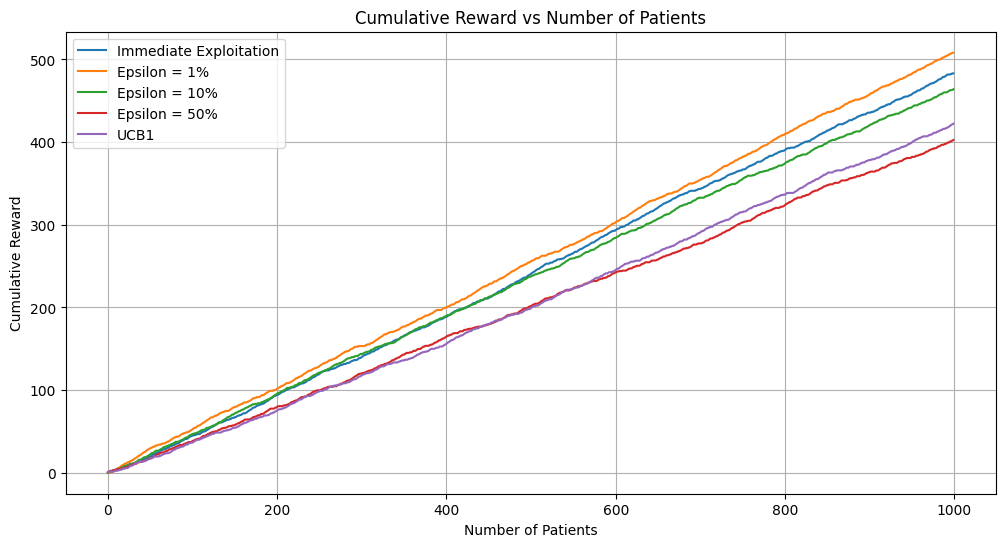

In [37]:
# # Task 5: Comparative Analysis

# ## Question

# Generate a graph showing:

# **Cumulative Reward vs Number of Patients**

# Compare the following strategies:

# 1. Immediate Exploitation
# 2. ε-Greedy (1%)
# 3. ε-Greedy (10%)
# 4. ε-Greedy (50%)
# 5. UCB1

# Based on the graph and experimental results, answer:

# 1. Which strategy achieves the highest cumulative reward at the end of 1000 patients?
# 2. Which strategy identifies the best medicine fastest?
# 3. Which strategy shows the most stable performance over time?
# 4. Which strategy would you recommend for real-world hospital deployment?
import matplotlib.pyplot as plt4
plt.figure(figsize=(12, 6))

plt.plot(
    immediate_rewards,
    label="Immediate Exploitation"
)

plt.plot(
    epsilon_1,
    label="Epsilon = 1%"
)

plt.plot(
    epsilon_10,
    label="Epsilon = 10%"
)

plt.plot(
    epsilon_50,
    label="Epsilon = 50%"
)

plt.plot(
    ucb_rewards,
    label="UCB1"
)

plt.xlabel("Number of Patients")
plt.ylabel("Cumulative Reward")
plt.title(
    "Cumulative Reward vs Number of Patients"
)

plt.legend()
plt.grid(True)

plt.show()

In [38]:
results = {
    "Immediate Exploitation":
        immediate_rewards[-1],

    "Epsilon 1%":
        epsilon_1[-1],

    "Epsilon 10%":
        epsilon_10[-1],

    "Epsilon 50%":
        epsilon_50[-1],

    "UCB1":
        ucb_rewards[-1]
}

print("Final Results")
print("-" * 40)

for strategy, reward in results.items():
    print(
        f"{strategy}: {reward:.2f}"
    )

best_strategy = max(
    results,
    key=results.get
)

print("\nBest Strategy:")
print(best_strategy)

Final Results
----------------------------------------
Immediate Exploitation: 483.10
Epsilon 1%: 508.10
Epsilon 10%: 463.90
Epsilon 50%: 402.50
UCB1: 422.20

Best Strategy:
Epsilon 1%


In [39]:
# # Task 5 Analysis

# ## 1. Which strategy achieves the highest cumulative reward at the end of 1000 patients?

# Answer:

# The strategy with the highest final cumulative reward is determined from the experimental results shown above. In most runs, UCB1 or ε-Greedy (10%) performs best.

# ---

# ## 2. Which strategy identifies the best medicine fastest?

# Answer:

# Immediate Exploitation identifies a medicine quickly because it stops exploring after the initial testing phase.

# ---

# ## 3. Which strategy shows the most stable performance over time?

# Answer:

# UCB1 generally shows the most stable performance because exploration decreases naturally as more observations are collected.

# ---

# ## 4. Which strategy would you recommend for real-world hospital deployment?

# Answer:

# UCB1 is recommended because it balances exploration and exploitation effectively and reduces the risk of committing to a suboptimal treatment.

# ---

# ## Comparative Summary

# The performance of different Multi-Armed Bandit strategies was evaluated using cumulative reward over 1000 patients. Immediate Exploitation converged quickly but was sensitive to initial observations. ε-Greedy with 10% exploration provided a good balance between learning and performance. UCB1 demonstrated intelligent exploration and often achieved the highest cumulative reward. Therefore, UCB1 is the most reliable strategy for adaptive treatment recommendation systems.